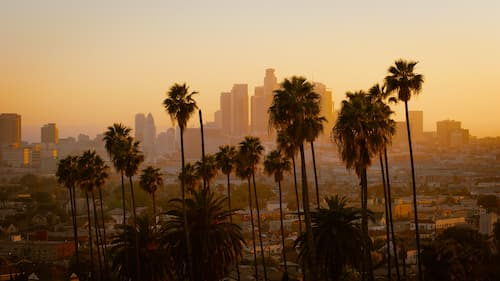

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [2]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [3]:
# Start coding here
# Use as many cells as you need

# Crimes per Hour

The hour with the highest frequency of crimes is: 12:00


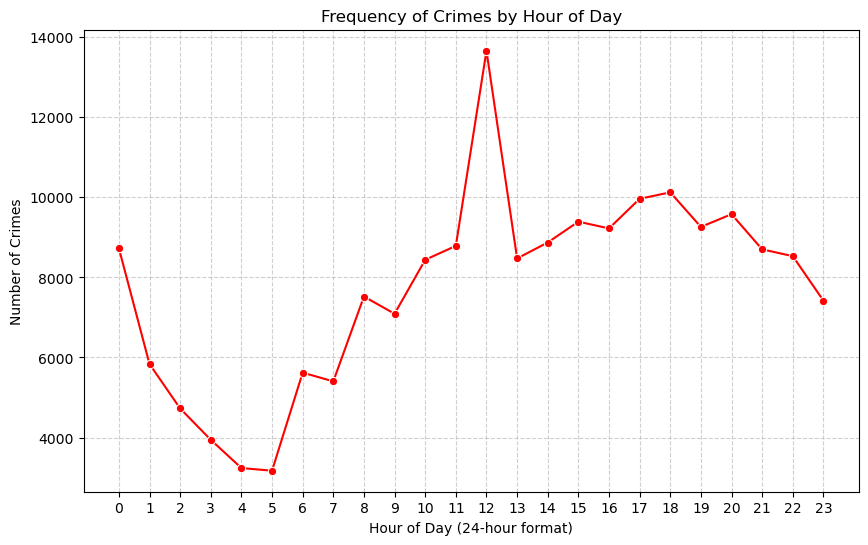

In [13]:
# Load the dataset
crimes = pd.read_csv('crimes.csv')

# 1. Extract the hour from 'TIME OCC'
# Using // 100 on 1330 gives 13 (1:00 PM)
crimes['hour'] = crimes['TIME OCC'] // 100

# 2. Count the number of crimes for each hour
hour_counts = crimes['hour'].value_counts().sort_index()

# 3. Find the peak hour
peak_crime_hour = hour_counts.idxmax()
print(f"The hour with the highest frequency of crimes is: {peak_crime_hour}:00")

# 4. Visualizign the results
plt.figure(figsize=(10, 6))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o', color='red')
plt.title('Frequency of Crimes by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Crimes per Areas

The area with the most reported crimes is: Central


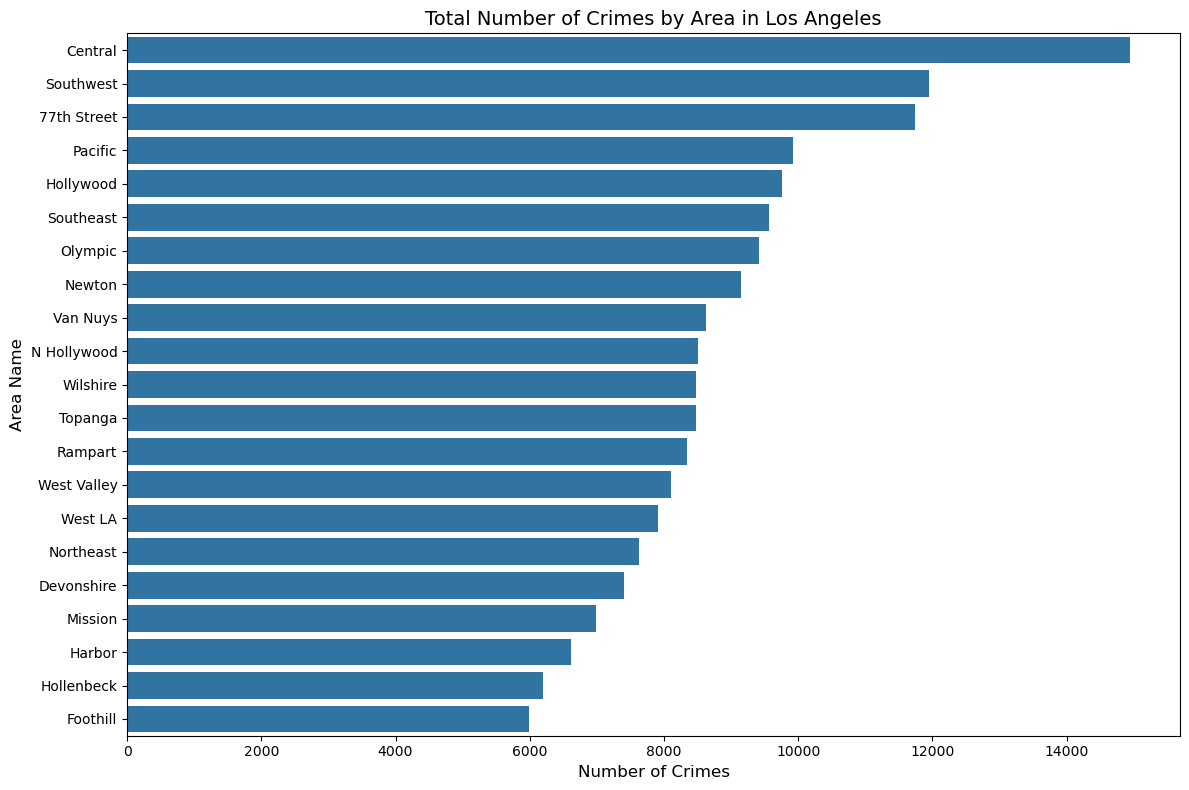

In [20]:
# Load the dataset
df = pd.read_csv('crimes.csv')
# 1. Count the number of crimes in each area
area_counts = df['AREA NAME'].value_counts()

# 2. Identify the area with the highest number of crimes
top_area = area_counts.idxmax()
print(f"The area with the most reported crimes is: {top_area}")

# 3. Visualize the distribution of crimes across all areas
plt.figure(figsize=(12, 8))
sns.barplot(x=area_counts.values, y=area_counts.index)

plt.title('Total Number of Crimes by Area in Los Angeles', fontsize=14)
plt.xlabel('Number of Crimes', fontsize=12)
plt.ylabel('Area Name', fontsize=12)
plt.tight_layout()
plt.show()

# Day of the Week

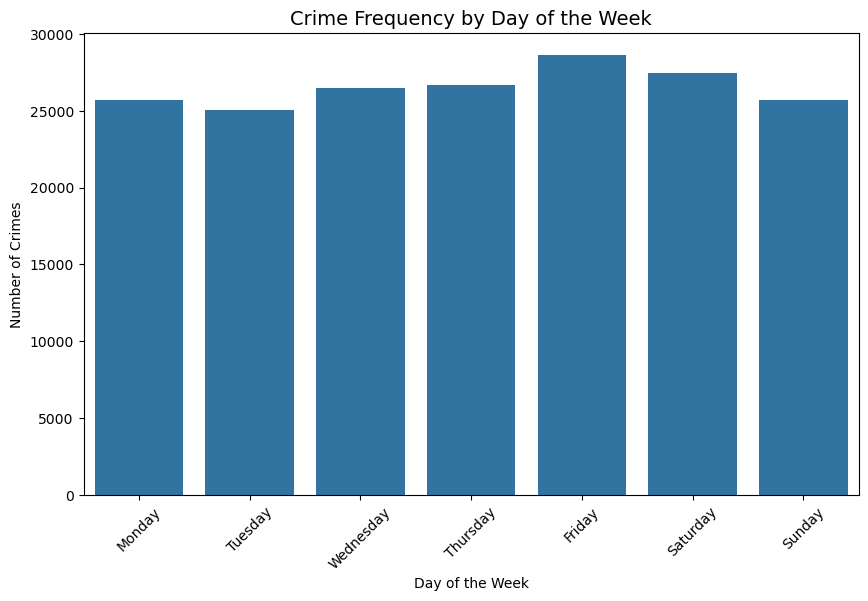

The day with the most reported crimes is: Friday with 28625 incidents.


In [17]:
# Load the dataset
df = pd.read_csv('crimes.csv')

# 1. Convert 'DATE OCC' to datetime format
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# 2. Extract the day of the week name
df['day_of_week'] = df['DATE OCC'].dt.day_name()

# 3. Set the chronological order for days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Count the number of crimes per day
day_counts = df['day_of_week'].value_counts().reindex(days_order)

# 5. Visualize the trends
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title('Crime Frequency by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()
print(f"The day with the most reported crimes is: {day_counts.idxmax()} with {day_counts.max()} incidents.")

# Reporting Lag Categories

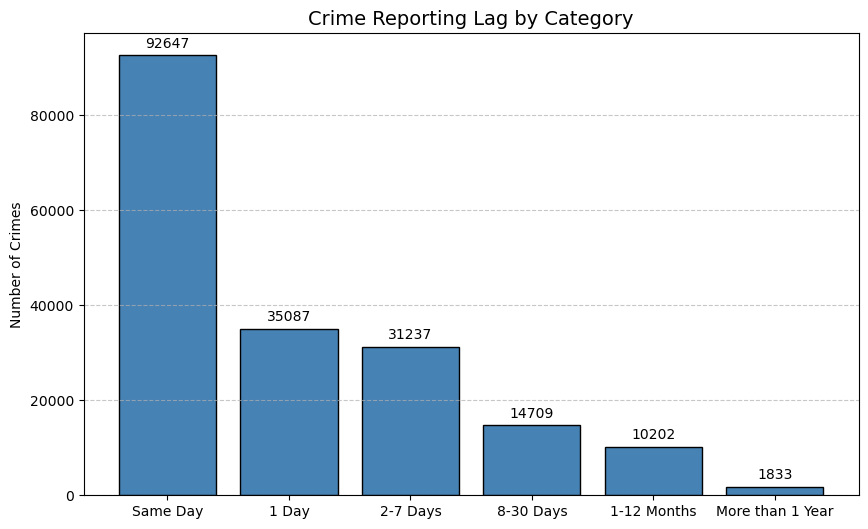

In [18]:
# Load and calculate lag
df = pd.read_csv('crimes.csv')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['reporting_lag'] = (df['Date Rptd'] - df['DATE OCC']).dt.days

# 1. Define logical time bins
bins = [-1, 0, 1, 7, 30, 365, df['reporting_lag'].max()]
labels = ['Same Day', '1 Day', '2-7 Days', '8-30 Days', '1-12 Months', 'More than 1 Year']

# 2. Categorize the data
df['lag_category'] = pd.cut(df['reporting_lag'], bins=bins, labels=labels)
lag_counts = df['lag_category'].value_counts().reindex(labels)

# 3. Create a clean Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(lag_counts.index, lag_counts.values, color='steelblue', edgecolor='black')

# Add number labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, int(yval), ha='center', va='bottom')

plt.title('Crime Reporting Lag by Category', fontsize=14)
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Top 10 Locations

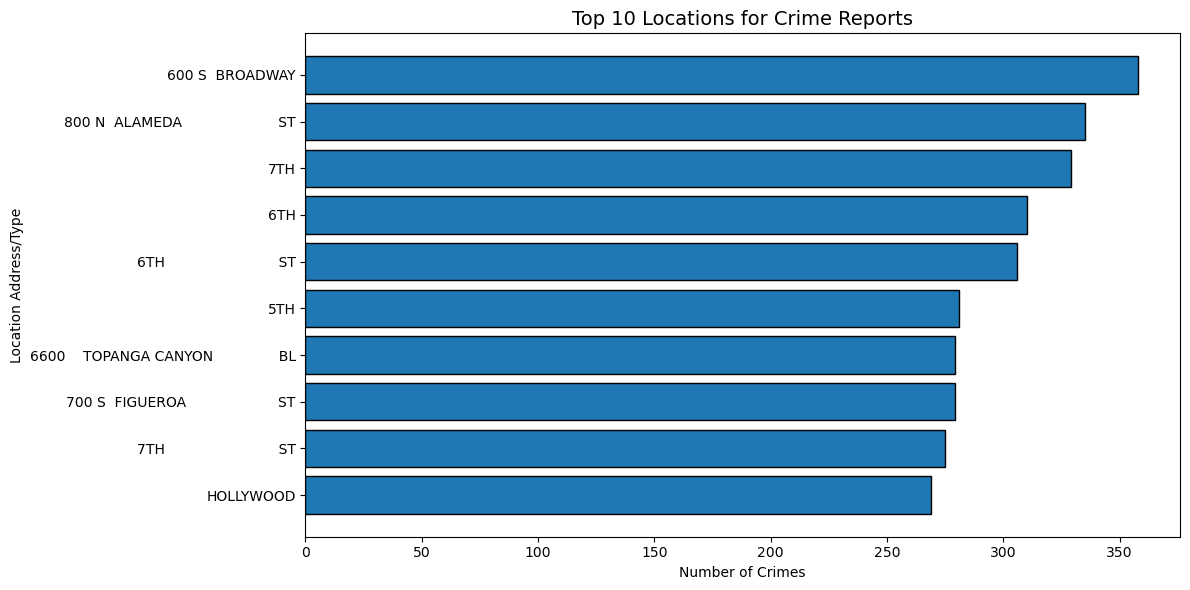

LOCATION
600 S  BROADWAY                            358
800 N  ALAMEDA                      ST     335
7TH                                        329
6TH                                        310
6TH                          ST            306
5TH                                        281
6600    TOPANGA CANYON               BL    279
700 S  FIGUEROA                     ST     279
7TH                          ST            275
HOLLYWOOD                                  269
Name: count, dtype: int64


In [23]:
# 1. Count the top 10 locations
top_locations = df['LOCATION'].value_counts().head(10)

# 2. Visualize
plt.figure(figsize=(12, 6))
plt.barh(top_locations.index, top_locations.values, edgecolor='black')
plt.gca().invert_yaxis() # Highest counts at the top

plt.title('Top 10 Locations for Crime Reports', fontsize=14)
plt.xlabel('Number of Crimes')
plt.ylabel('Location Address/Type')
plt.tight_layout()
plt.show()

print(top_locations)

# Area vs. Crime Type Heatmap

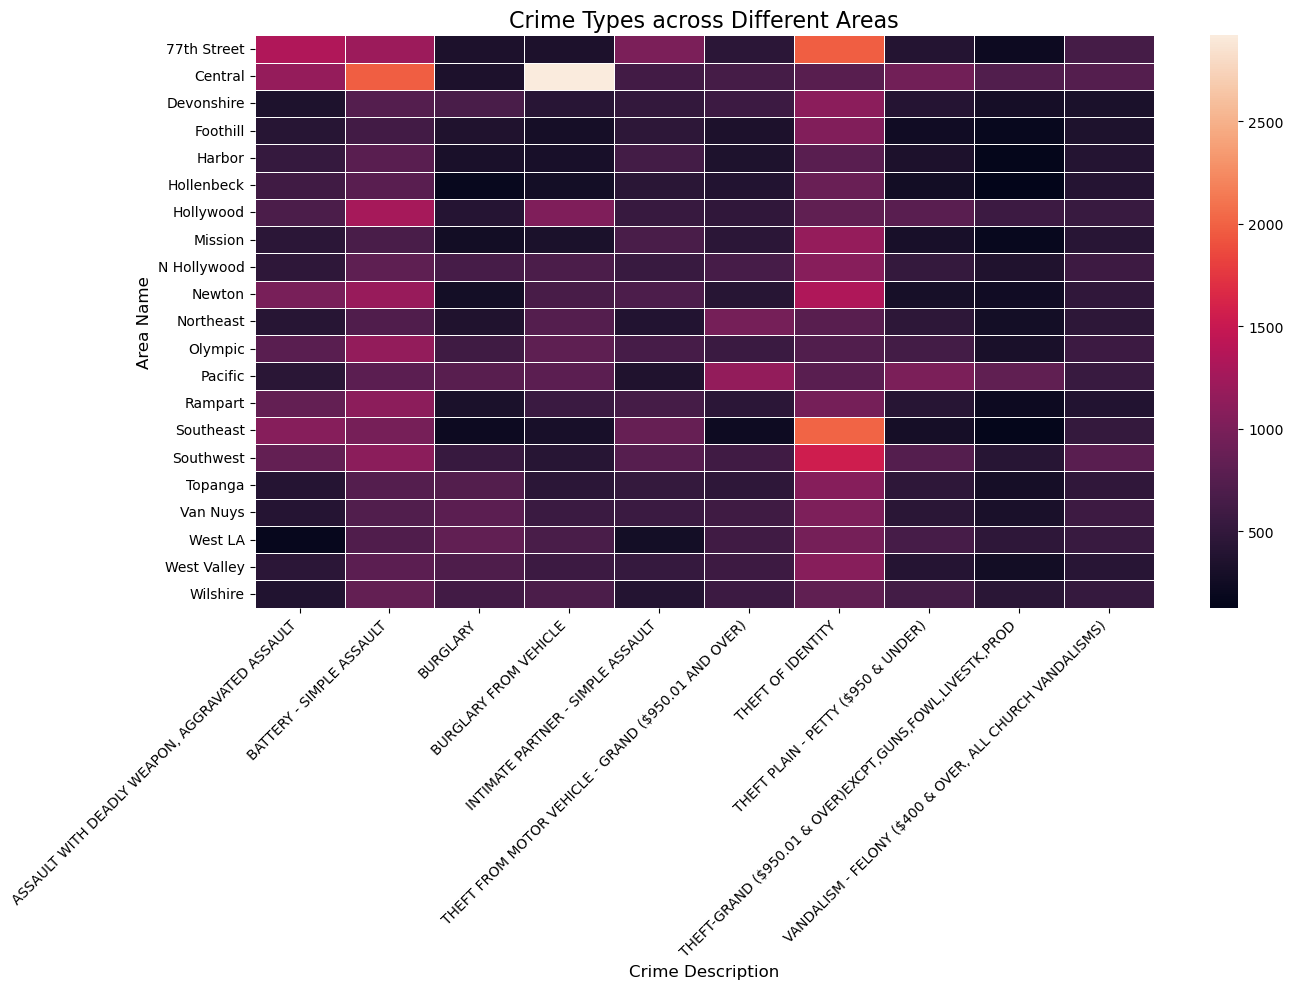

In [34]:
# Load the dataset
df = pd.read_csv('crimes.csv')

# 1. Identify the Top 10 most common crime types
top_10_crimes = df['Crm Cd Desc'].value_counts().nlargest(10).index
df_filtered = df[df['Crm Cd Desc'].isin(top_10_crimes)]

# 2. Create a pivot table (Crosstab) of Areas vs. Crime Types
heatmap_data = pd.crosstab(df_filtered['AREA NAME'], df_filtered['Crm Cd Desc'])

# 3. Plot the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=False, linewidths=.5)

plt.title('Crime Types across Different Areas', fontsize=16)
plt.xlabel('Crime Description', fontsize=12)
plt.ylabel('Area Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Victims Age Distribution

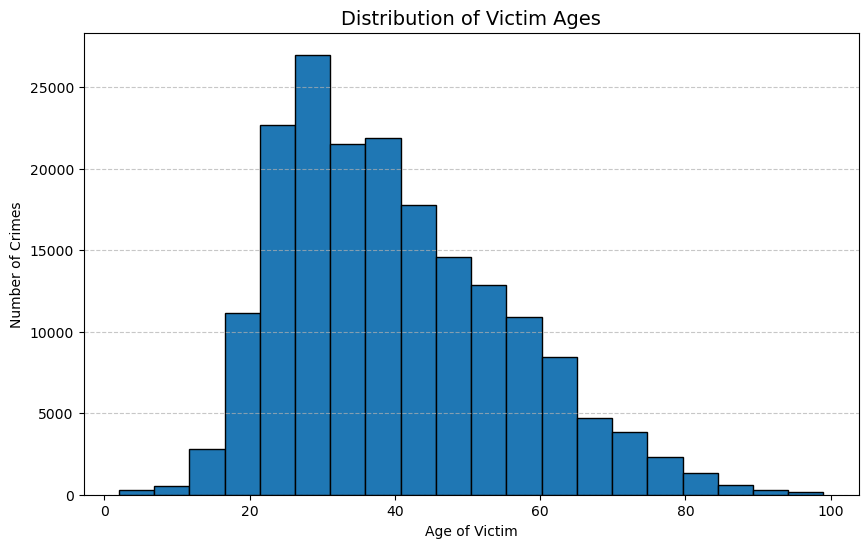

Average Victim Age: 40.0 years
Most frequent age group: 25-35 years old


In [31]:
# Load the dataset
df = pd.read_csv('crimes.csv')

# 1. Filter out ages that are 0 or less
vict_age_filtered = df[df['Vict Age'] > 0]['Vict Age']

# 2. Visualize with a Histogram
plt.figure(figsize=(10, 6))
plt.hist(vict_age_filtered, bins=20, edgecolor='black')

plt.title('Distribution of Victim Ages', fontsize=14)
plt.xlabel('Age of Victim')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f"Average Victim Age: {vict_age_filtered.mean():.1f} years")
print(f"Most frequent age group: 25-35 years old")

# Victims Demographics Regarding Gender and Descent

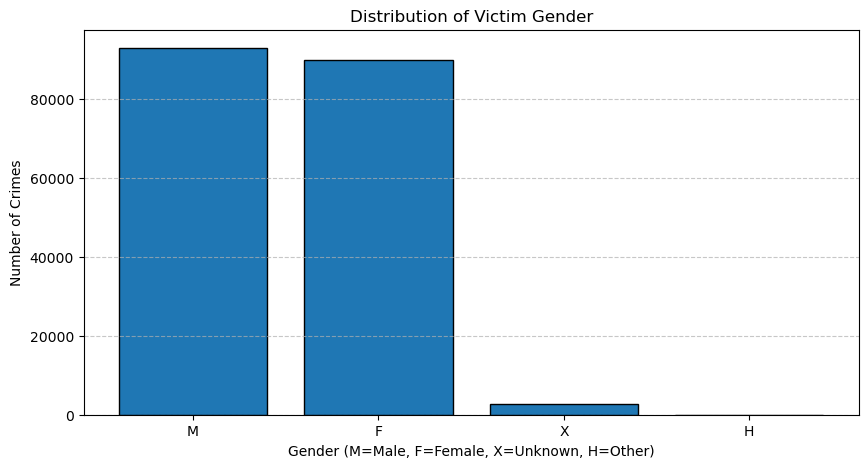

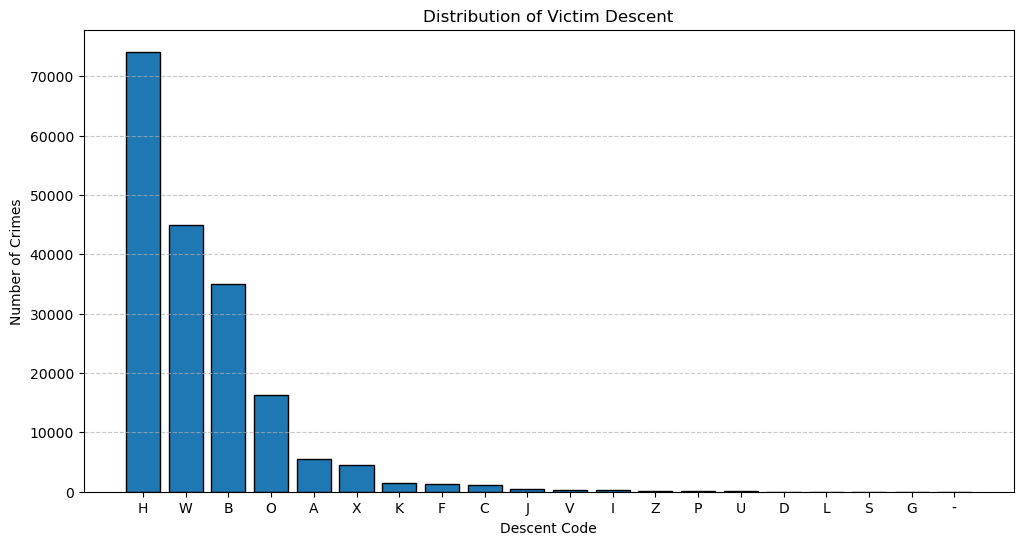

In [36]:
# Load the dataset
df = pd.read_csv('crimes.csv')

# 1. Victim Gender Analysis
sex_counts = df['Vict Sex'].value_counts()

# 2. Victim Descent Analysis
descent_counts = df['Vict Descent'].value_counts()

# Plotting Gender Distribution
plt.figure(figsize=(10, 5))
plt.bar(sex_counts.index, sex_counts.values, edgecolor='black')
plt.title('Distribution of Victim Gender')
plt.xlabel('Gender (M=Male, F=Female, X=Unknown, H=Other)')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plotting Descent Distribution
plt.figure(figsize=(12, 6))
plt.bar(descent_counts.index, descent_counts.values, edgecolor='black')
plt.title('Distribution of Victim Descent')
plt.xlabel('Descent Code')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()